In [2]:
# notebooks/02_severity_engineering.py

import pandas as pd

df = pd.read_csv("../dataset/cleaned_events.csv")

df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    format="mixed",
    errors="coerce",
    utc=True
)

df["end_datetime"] = pd.to_datetime(
    df["end_datetime"],
    format="mixed",
    errors="coerce",
    utc=True
)

df["hour"] = df["start_datetime"].dt.hour

In [3]:
def create_severity(row):

    score = 0

    # priority

    if row["priority"] == "High":
        score += 3

    # road closure

    if row["requires_road_closure"] == True:
        score += 3

    # unplanned event

    if row["event_type"] == "unplanned":
        score += 2

    # cause

    if row["event_cause"] in [
        "accident",
        "water_logging",
        "construction",
        "public_event",
        "procession",
        "vip_movement",
        "protest"
    ]:
        score += 2

    # peak hours

    if row["hour"] in [5,6,19,20,21]:
        score += 1

    # hot zones

    if row["zone"] in [
        "Central Zone 2",
        "West Zone 1",
        "North Zone 2"
    ]:
        score += 1

    # final label

    if score >= 8:
        return "Critical"

    elif score >= 6:
        return "High"

    elif score >= 3:
        return "Medium"

    else:
        return "Low"

In [10]:
df["severity"] = df.apply(
    create_severity,
    axis=1
)

In [11]:
print(
    df["severity"].value_counts()
)

severity
Medium      3760
High        2759
Low         1103
Critical     551
Name: count, dtype: int64


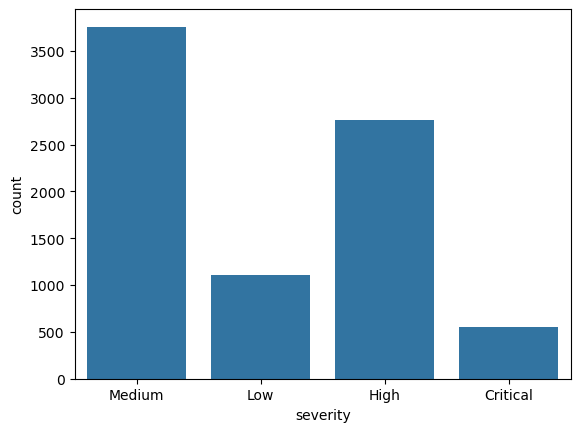

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="severity"
)

plt.show()

In [7]:
df.to_csv(
    "../dataset/severity_dataset.csv",
    index=False
)